In [1]:
import nltk
import pandas as pd

nltk.download("movie_reviews")
nltk.download("stopwords")
nltk.download("wordnet")

from nltk.corpus import movie_reviews
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package movie_reviews to C:\Users\Kumar
[nltk_data]     Ansuman\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.
[nltk_data] Downloading package stopwords to C:\Users\Kumar
[nltk_data]     Ansuman\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to C:\Users\Kumar
[nltk_data]     Ansuman\AppData\Roaming\nltk_data...


In [2]:
documents = []

for category in movie_reviews.categories():
    for file_id in movie_reviews.fileids(category):
        review_text = movie_reviews.raw(file_id)
        documents.append({
            "review": review_text,
            "sentiment": category
        })

df = pd.DataFrame(documents)

df.head()

,review,sentiment
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard's quick movie review \ndamn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' firs...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


In [3]:
print("Dataset shape:", df.shape)

print("\nSentiment counts:")
print(df["sentiment"].value_counts())

print("\nExample review:")
print(df.loc[0, "review"])

print("\nLabel:")
print(df.loc[0, "sentiment"])

Dataset shape: (2000, 2)

Sentiment counts:
sentiment
neg    1000
pos    1000
Name: count, dtype: int64

Example review:
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
i

In [4]:
import re

stop_words = set(stopwords.words("english"))

# Keep negation words because they are important for sentiment
negation_words = {"not", "no", "nor", "never"}

stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()


def clean_review(text):
    # 1. Convert all text to lowercase
    text = text.lower()

    # 2. Keep only letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    # 3. Split text into individual words
    words = text.split()

    # 4. Remove stopwords and lemmatize remaining words
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # 5. Join the cleaned words back into one string
    return " ".join(cleaned_words)

In [5]:
raw_review = df.loc[0, "review"]
cleaned_review = clean_review(raw_review)

print("RAW REVIEW:\n")
print(raw_review[:500])

print("\nCLEANED REVIEW:\n")
print(cleaned_review[:500])

RAW REVIEW:

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt

CLEANED REVIEW:

plot two teen couple go church party drink drive get accident one guy dy girlfriend continues see life nightmare deal watch movie sorta find critique mind fuck movie teen generation touch cool idea present bad package make review even harder one write since generally applaud film attempt break mold mess head lost highway memento good bad way making type film folk snag one correctly seem taken pretty neat concept executed terribly problem movie well main problem si

In [6]:
df["cleaned_review"] = df["review"].apply(clean_review)

df[["review", "cleaned_review", "sentiment"]].head()

,review,cleaned_review,sentiment
0,"plot : two teen couples go to a church party ,...",plot two teen couple go church party drink dri...,neg
1,the happy bastard's quick movie review \ndamn ...,happy bastard quick movie review damn k bug go...,neg
2,it is movies like these that make a jaded movi...,movie like make jaded movie viewer thankful in...,neg
3,""" quest for camelot "" is warner bros . ' firs...",quest camelot warner bros first feature length...,neg
4,synopsis : a mentally unstable man undergoing ...,synopsis mentally unstable man undergoing psyc...,neg


In [7]:
print("Empty cleaned reviews:", (df["cleaned_review"].str.len() == 0).sum())

Empty cleaned reviews: 0


In [8]:
X = df["cleaned_review"]
y = df["sentiment"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training reviews:", X_train.shape[0])
print("Testing reviews:", X_test.shape[0])

print("\nTraining-label distribution:")
print(y_train.value_counts())

print("\nTesting-label distribution:")
print(y_test.value_counts())

Training reviews: 1600
Testing reviews: 400

Training-label distribution:
sentiment
pos    800
neg    800
Name: count, dtype: int64

Testing-label distribution:
sentiment
neg    200
pos    200
Name: count, dtype: int64


In [10]:
bow_vectorizer = CountVectorizer()

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("Training BoW shape:", X_train_bow.shape)
print("Testing BoW shape:", X_test_bow.shape)

Training BoW shape: (1600, 31536)
Testing BoW shape: (400, 31536)


In [11]:
tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1600, 31536)
Testing TF-IDF shape: (400, 31536)


In [12]:
nb_bow_model = MultinomialNB()

nb_bow_model.fit(X_train_bow, y_train)

y_pred_nb_bow = nb_bow_model.predict(X_test_bow)

print(classification_report(y_test, y_pred_nb_bow))

              precision    recall  f1-score   support

         neg       0.82      0.81      0.82       200
         pos       0.81      0.82      0.82       200

    accuracy                           0.82       400
   macro avg       0.82      0.82      0.82       400
weighted avg       0.82      0.82      0.82       400



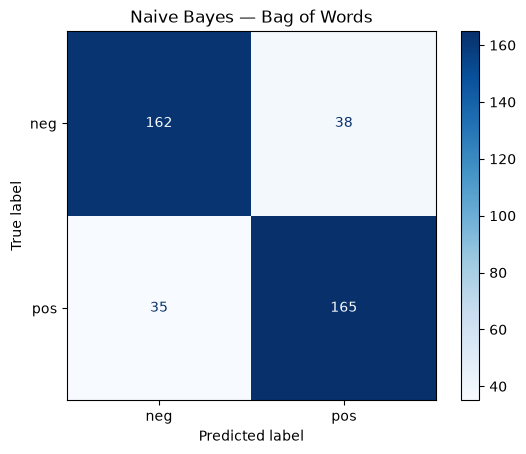

In [13]:
cm = confusion_matrix(y_test, y_pred_nb_bow)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_bow_model.classes_
).plot(cmap="Blues")

plt.title("Naive Bayes — Bag of Words")
plt.show()

In [14]:
# Train Naive Bayes using TF-IDF features
nb_tfidf_model = MultinomialNB()

nb_tfidf_model.fit(X_train_tfidf, y_train)

# Predict sentiment for unseen test reviews
y_pred_nb_tfidf = nb_tfidf_model.predict(X_test_tfidf)

# Evaluation report
print(classification_report(y_test, y_pred_nb_tfidf))

              precision    recall  f1-score   support

         neg       0.80      0.83      0.82       200
         pos       0.82      0.80      0.81       200

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400



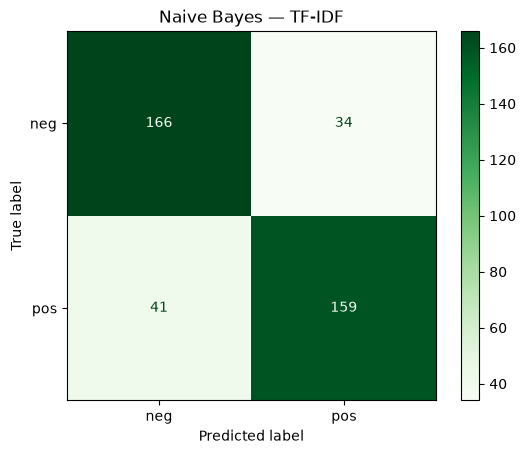

In [15]:
cm = confusion_matrix(y_test, y_pred_nb_tfidf)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_tfidf_model.classes_
).plot(cmap="Greens")

plt.title("Naive Bayes — TF-IDF")
plt.show()

In [16]:
lr_bow_model = LogisticRegression(max_iter=1000)

lr_bow_model.fit(X_train_bow, y_train)

y_pred_lr_bow = lr_bow_model.predict(X_test_bow)

print(classification_report(y_test, y_pred_lr_bow))

              precision    recall  f1-score   support

         neg       0.87      0.81      0.84       200
         pos       0.82      0.88      0.85       200

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



In [17]:
lr_tfidf_model = LogisticRegression(max_iter=1000)

lr_tfidf_model.fit(X_train_tfidf, y_train)

y_pred_lr_tfidf = lr_tfidf_model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_lr_tfidf))

              precision    recall  f1-score   support

         neg       0.85      0.81      0.83       200
         pos       0.82      0.86      0.84       200

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



In [25]:
final_model = lr_bow_model
final_vectorizer = bow_vectorizer

In [ ]:
def predict_sentiment(review):
    cleaned_text = clean_review(review)

    # Convert with the SAME vectorizer used while training final_model
    review_vector = final_vectorizer.transform([cleaned_text])

    prediction = final_model.predict(review_vector)[0]
    probabilities = final_model.predict_proba(review_vector)[0]

    return prediction, probabilities.max()

In [22]:
review = "The movie was amazing. I loved the acting and the story."

prediction, confidence = predict_sentiment(review)

print("Sentiment:", prediction)
print(f"Confidence: {confidence:.2%}")

Sentiment: neg
Confidence: 71.77%


In [21]:
review = "This was a boring movie with terrible acting and a weak story."

prediction, confidence = predict_sentiment(review)

print("Sentiment:", prediction)
print(f"Confidence: {confidence:.2%}")

Sentiment: neg
Confidence: 89.02%


In [23]:
reviews_to_test = [
    "I absolutely loved this movie. The performances were brilliant and the story was engaging.",
    
    "A wonderful film with emotional moments, great music, and excellent acting.",
    
    "This movie was terrible. The plot was confusing and the acting was disappointing.",
    
    "I regret watching this film. It was boring, slow, and completely predictable.",
    
    "The movie started well, but the second half was too long and disappointing.",
    
    "The visuals were beautiful, but the story was weak and the characters were dull.",
    
    "Not bad at all. I enjoyed the acting and would watch it again.",
    
    "The movie was not good. It had no interesting scenes and wasted my time."
]

In [24]:
for review in reviews_to_test:
    prediction, confidence = predict_sentiment(review)
    
    print("Review:", review)
    print("Predicted sentiment:", prediction)
    print(f"Confidence: {confidence:.2%}")
    print("-" * 80)

Review: I absolutely loved this movie. The performances were brilliant and the story was engaging.
Predicted sentiment: neg
Confidence: 53.96%
--------------------------------------------------------------------------------
Review: A wonderful film with emotional moments, great music, and excellent acting.
Predicted sentiment: neg
Confidence: 52.24%
--------------------------------------------------------------------------------
Review: This movie was terrible. The plot was confusing and the acting was disappointing.
Predicted sentiment: neg
Confidence: 89.56%
--------------------------------------------------------------------------------
Review: I regret watching this film. It was boring, slow, and completely predictable.
Predicted sentiment: neg
Confidence: 88.98%
--------------------------------------------------------------------------------
Review: The movie started well, but the second half was too long and disappointing.
Predicted sentiment: neg
Confidence: 76.71%
-------------

In [26]:
for i in range(5):
    review = X_test.iloc[i]
    actual = y_test.iloc[i]

    predicted = final_model.predict(
        final_vectorizer.transform([review])
    )[0]

    print("Actual:", actual)
    print("Predicted:", predicted)
    print("-" * 50)

Actual: neg
Predicted: neg
--------------------------------------------------
Actual: neg
Predicted: neg
--------------------------------------------------
Actual: pos
Predicted: pos
--------------------------------------------------
Actual: neg
Predicted: pos
--------------------------------------------------
Actual: neg
Predicted: neg
--------------------------------------------------


In [27]:
reviews_to_test = [
    # Clearly positive
    "An excellent movie with a beautiful story and fantastic performances.",
    "I loved every minute of this film. It was funny, emotional, and memorable.",
    "The acting was outstanding and the ending was satisfying.",

    # Clearly negative
    "This was a terrible movie with weak acting and a boring plot.",
    "I hated this film. It was slow, confusing, and a complete waste of time.",
    "The story made no sense and the characters were extremely dull.",

    # Mixed / difficult cases
    "The first half was enjoyable, but the ending was disappointing.",
    "Great visuals and music, although the story was not very interesting.",
    "The actors did a good job, but the movie itself was too long."
]

for review in reviews_to_test:
    prediction, confidence = predict_sentiment(review)

    print("Review:", review)
    print("Predicted:", prediction)
    print(f"Confidence: {confidence:.2%}")
    print("-" * 80)

Review: An excellent movie with a beautiful story and fantastic performances.
Predicted: pos
Confidence: 51.66%
--------------------------------------------------------------------------------
Review: I loved every minute of this film. It was funny, emotional, and memorable.
Predicted: neg
Confidence: 65.36%
--------------------------------------------------------------------------------
Review: The acting was outstanding and the ending was satisfying.
Predicted: neg
Confidence: 66.33%
--------------------------------------------------------------------------------
Review: This was a terrible movie with weak acting and a boring plot.
Predicted: neg
Confidence: 91.97%
--------------------------------------------------------------------------------
Review: I hated this film. It was slow, confusing, and a complete waste of time.
Predicted: neg
Confidence: 83.08%
--------------------------------------------------------------------------------
Review: The story made no sense and the charact

In [28]:
import joblib

final_model = lr_bow_model
final_vectorizer = bow_vectorizer

joblib.dump(final_model, "sentiment_model.pkl")
joblib.dump(final_vectorizer, "vectorizer.pkl")

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.
